1. Generating Network (N=400)...
2. Integrating GLV Dynamics to find true fixed point (this may take a moment)...
3. Extinctions processed. 196/400 species survived.


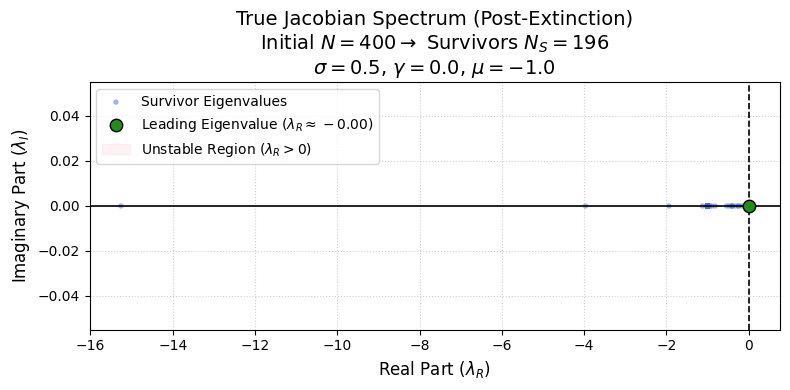

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from glv.graph import generate_network


def plot_true_survivor_spectrum(N, mean_degree, sigma, gamma, mu):
    print(f"1. Generating Network (N={N})...")
    raw_sequence = np.random.exponential(mean_degree, N)
    W, G = generate_network(raw_sequence, sigma, gamma, mu)

    print("2. Integrating GLV Dynamics to find true fixed point (this may take a moment)...")
    def glv_deriv(t, x):
        x_safe = np.maximum(x, 0)
        return x_safe * (1.0 - x_safe + W @ x_safe)

    x0 = np.random.uniform(0.8, 1.2, N)

    sol = solve_ivp(glv_deriv, [0, 100], x0, method='BDF')

    x_final = sol.y[:, -1]

    survivors = x_final > 1e-4
    N_surv = np.sum(survivors)
    print(f"3. Extinctions processed. {N_surv}/{N} species survived.")

    if N_surv == 0:
        print("Total ecosystem collapse! No eigenvalues to plot.")
        return

    W_surv = W[np.ix_(survivors, survivors)]
    x_surv = x_final[survivors]

    J_surv = np.diag(x_surv) @ (W_surv - np.eye(N_surv))

    eigenvalues = np.linalg.eigvals(J_surv)
    max_real_idx = np.argmax(eigenvalues.real)
    leading_eigenvalue = eigenvalues[max_real_idx]

    plt.figure(figsize=(8, 4), dpi=100)

    plt.scatter(eigenvalues.real, eigenvalues.imag, alpha=0.5, s=15,
                color='royalblue', edgecolors='none', label='Survivor Eigenvalues')

    is_stable = leading_eigenvalue.real <= 1e-5
    leading_color = 'forestgreen' if is_stable else 'crimson'

    plt.scatter(leading_eigenvalue.real, leading_eigenvalue.imag,
                color=leading_color, s=80, zorder=5, edgecolor='black', linewidth=1,
                label=rf'Leading Eigenvalue ($\lambda_R \approx {leading_eigenvalue.real:.2f}$)')

    plt.axhline(0, color='black', linewidth=1.2)
    plt.axvline(0, color='black', linewidth=1.2, linestyle='--')

    x_max = max(eigenvalues.real)
    plt.axvspan(0, x_max, color='crimson', alpha=0.05, label=r'Unstable Region ($\lambda_R > 0$)')

    plt.xlabel(r'Real Part ($\lambda_R$)', fontsize=12)
    plt.ylabel(r'Imaginary Part ($\lambda_I$)', fontsize=12)

    title = (f"True Jacobian Spectrum (Post-Extinction)\n"
             rf"Initial $N={N} \rightarrow$ Survivors $N_S={N_surv}$" "\n"
             rf"$\sigma={sigma}$, $\gamma={gamma}$, $\mu={mu}$")
    plt.title(title, fontsize=14)

    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()


PARAMS = {
    'N': 400,
    'mean_degree': 10,
    'sigma': 0.5,
    'gamma': 0.0,
    'mu': -1.0,
}

plot_true_survivor_spectrum(**PARAMS)